In [114]:
from PIL import Image
import numpy as np
import torch
#   albedo RMSE vs GT: 0.1617  (scale-norm=True)
fg_est = torch.tensor(np.asarray(Image.open(r"raw_optimizer_results\scene_0000\no reg\albedo_est.png")) / 255)
fg_gt = torch.tensor(np.asarray(Image.open(r"raw_optimizer_results\scene_0000\no reg\albedo_gt.png")) / 255)
mask = fg_gt > 0

In [115]:
# fg_est = fg_est[mask]
# fg_gt = fg_gt[mask]

In [116]:
fg_est.mean((0,1)), fg_gt.mean((0,1))

(tensor([0.0572, 0.0542, 0.0533], dtype=torch.float64),
 tensor([0.0218, 0.0180, 0.0127], dtype=torch.float64))

In [117]:
# scale = fg_est.max((0,1)) / (fg_gt.max((0,1)) + 1e-8)
# scale = fg_est.mean((0,1)) / (fg_gt.mean((0,1)) + 1e-8) 

numerator   = (fg_gt * fg_est).sum(dim=(0,1))   # (3,)
denominator = (fg_est * fg_est).sum(dim=(0,1))  # (3,)
scale = numerator / denominator

fg_est = fg_est * scale

np.sqrt(((fg_est - fg_gt) ** 2).mean())

C:\Users\felix\AppData\Local\Temp\ipykernel_25268\2413998783.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.sqrt(((fg_est - fg_gt) ** 2).mean())


tensor(0.0715, dtype=torch.float64)

In [118]:
scale

tensor([1.2279, 1.1462, 1.0015], dtype=torch.float64)

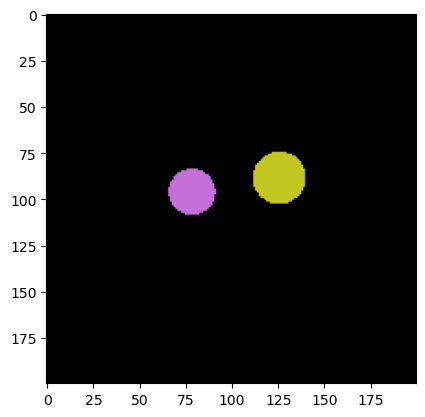

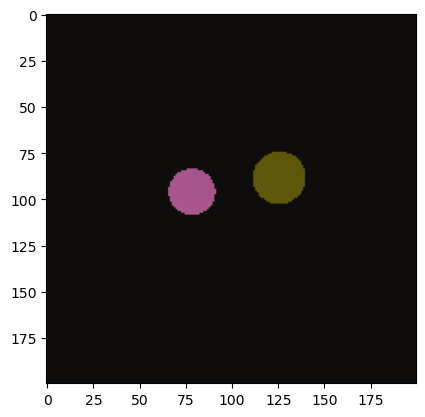

In [119]:
import matplotlib.pyplot as plt

plt.imshow(fg_gt)
plt.show()
plt.imshow(fg_est)